# Feature Engineering

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split , GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix , roc_curve, roc_auc_score , ConfusionMatrixDisplay

In [7]:
dataset = pd.read_csv("Heart")
dataset

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,297,68,0,3,120,211.0,0,0,115,0,1.5,1,1
1044,298,44,0,3,108,141.0,0,1,175,0,0.6,1,1
1045,299,52,1,1,128,255.0,0,1,161,1,0.0,2,0
1046,300,59,1,4,160,273.0,0,0,125,0,0.0,2,0


In [9]:
df = pd.DataFrame(dataset)
df

,Unnamed: 0,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,297,68,0,3,120,211.0,0,0,115,0,1.5,1,1
1044,298,44,0,3,108,141.0,0,1,175,0,0.6,1,1
1045,299,52,1,1,128,255.0,0,1,161,1,0.0,2,0
1046,300,59,1,4,160,273.0,0,0,125,0,0.0,2,0


In [11]:
df.drop("Unnamed: 0" , axis = 1 , inplace = True)
df

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1043,68,0,3,120,211.0,0,0,115,0,1.5,1,1
1044,44,0,3,108,141.0,0,1,175,0,0.6,1,1
1045,52,1,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,1,4,160,273.0,0,0,125,0,0.0,2,0


### Incorrect Values.

In [13]:
df.replace({'ST slope': 0}, np.nan, inplace=True)
df['ST slope'] = df['ST slope'].fillna(df['ST slope'].mode()[0])

### Handling Outliers 

In [15]:
import numpy as np

def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = np.where(df[col] < lower, lower,
                    np.where(df[col] > upper, upper, df[col]))
    return df

# Example: apply on key continuous columns
cols_to_cap = ['resting bps', 'cholesterol', 'max heart rate']
df_capped = cap_outliers(df.copy(), cols_to_cap)

df_capped

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140.0,289.0,0,0,172.0,0,0.0,1.0,0
1,49,0,3,160.0,180.0,0,0,156.0,0,1.0,2.0,1
2,37,1,2,130.0,283.0,0,1,98.0,0,0.0,1.0,0
3,48,0,4,138.0,214.0,0,0,108.0,1,1.5,2.0,1
4,54,1,3,150.0,195.0,0,0,122.0,0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1043,68,0,3,120.0,211.0,0,0,115.0,0,1.5,1.0,1
1044,44,0,3,108.0,141.0,0,1,175.0,0,0.6,1.0,1
1045,52,1,1,128.0,255.0,0,1,161.0,1,0.0,2.0,0
1046,59,1,4,160.0,273.0,0,0,125.0,0,0.0,2.0,0


## Before applying Feature Scaling part we do the simple visualization that which numeric input feature follows Normal distribution. 

In [17]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns = ['target']), df.iloc[:,-1] , test_size = 0.2, random_state = 42)

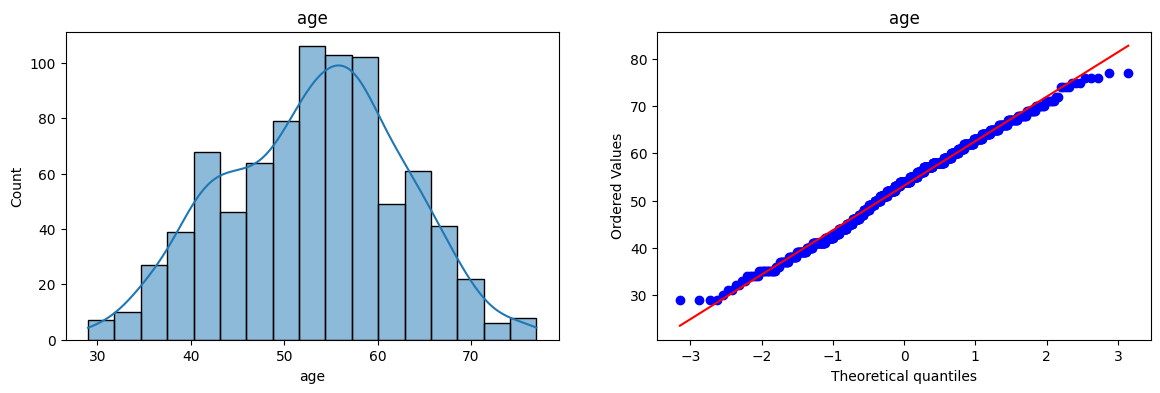

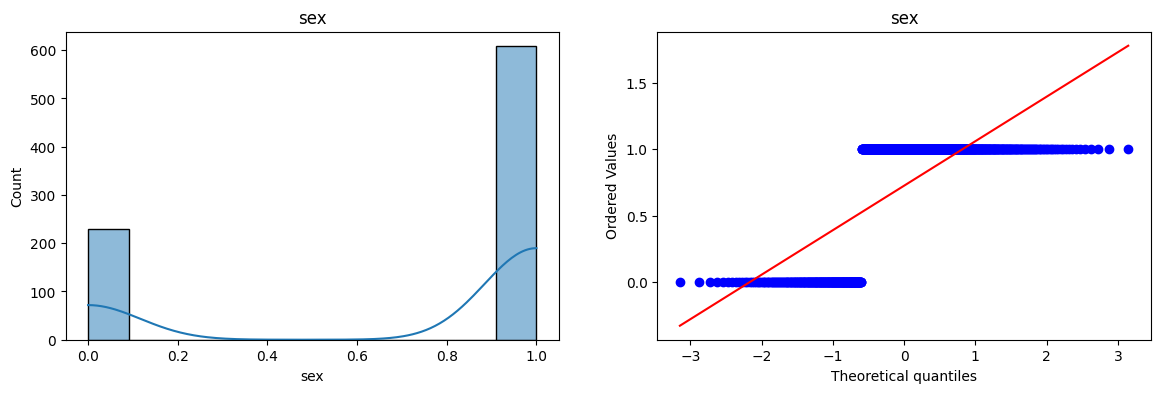

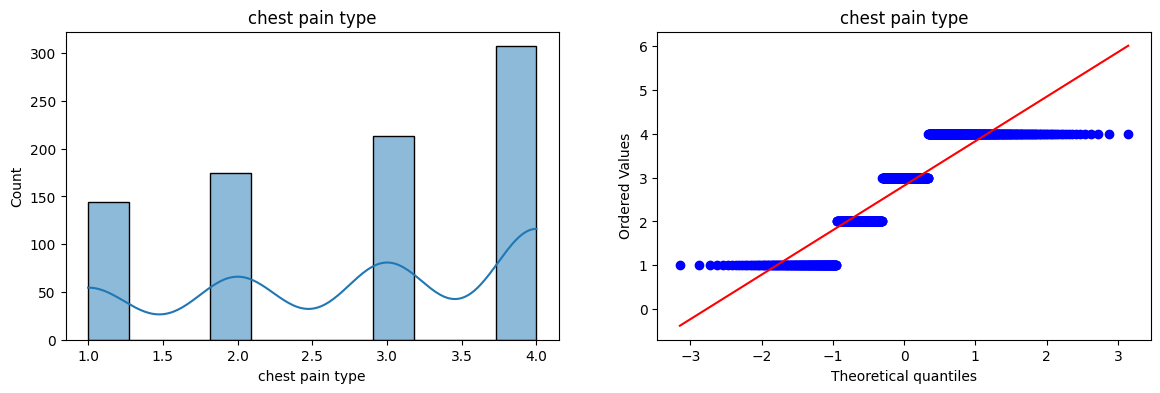

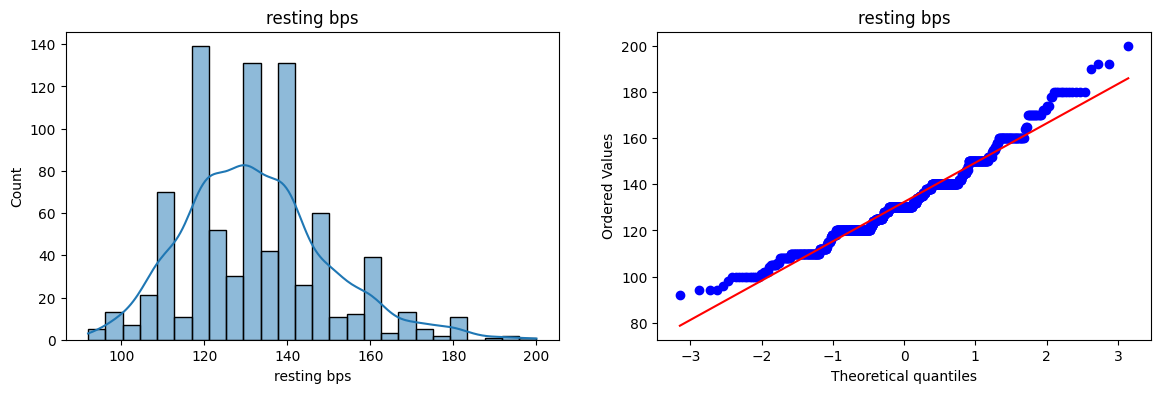

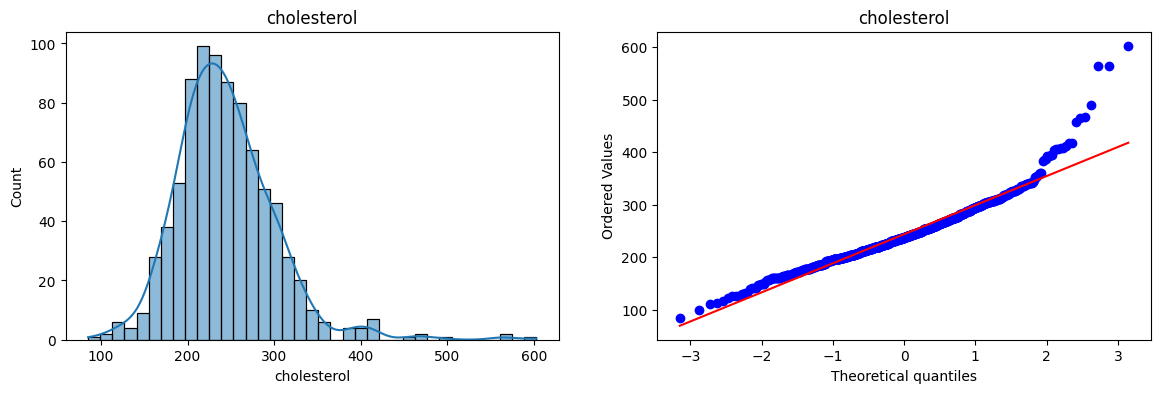

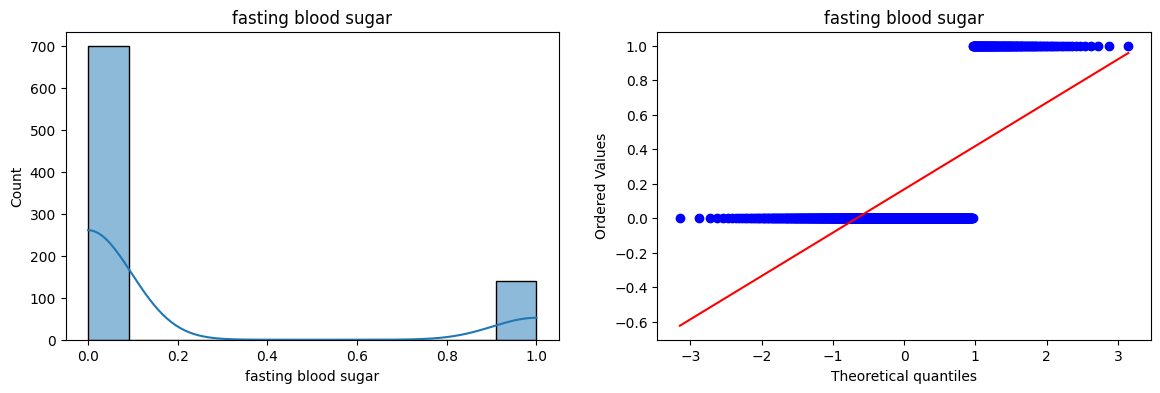

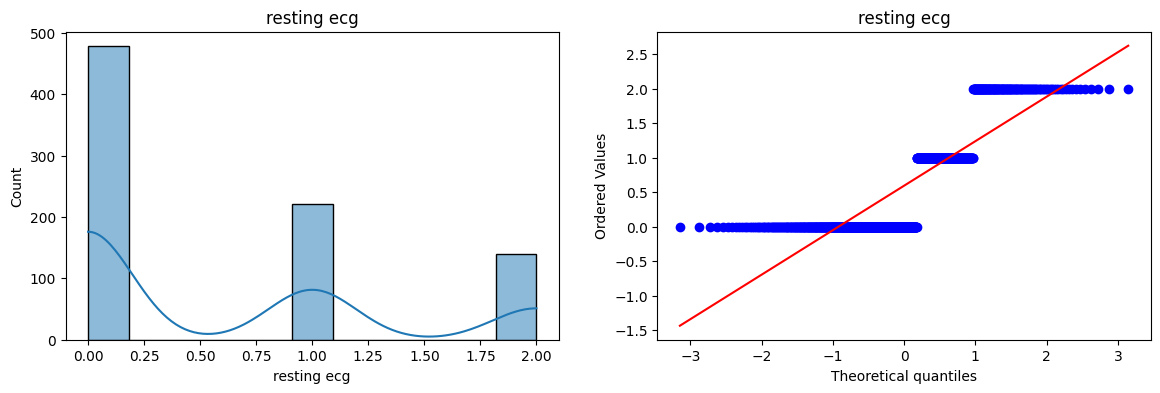

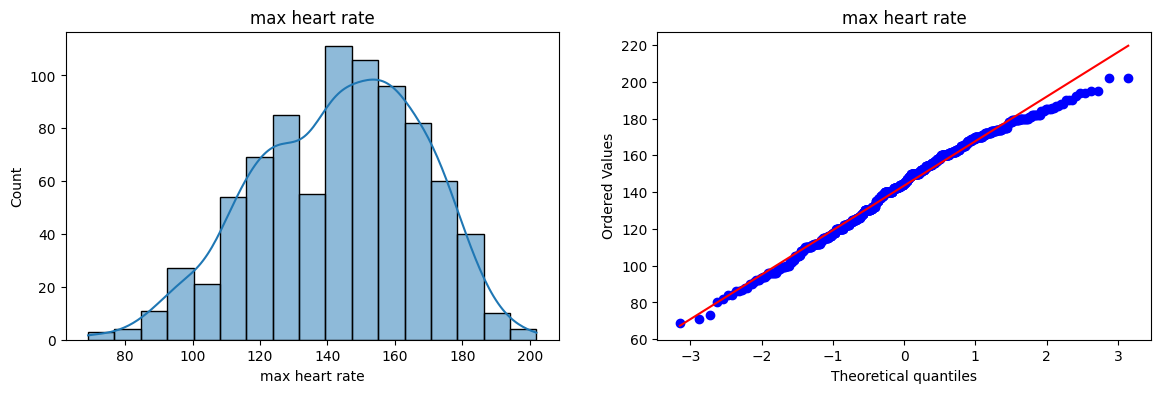

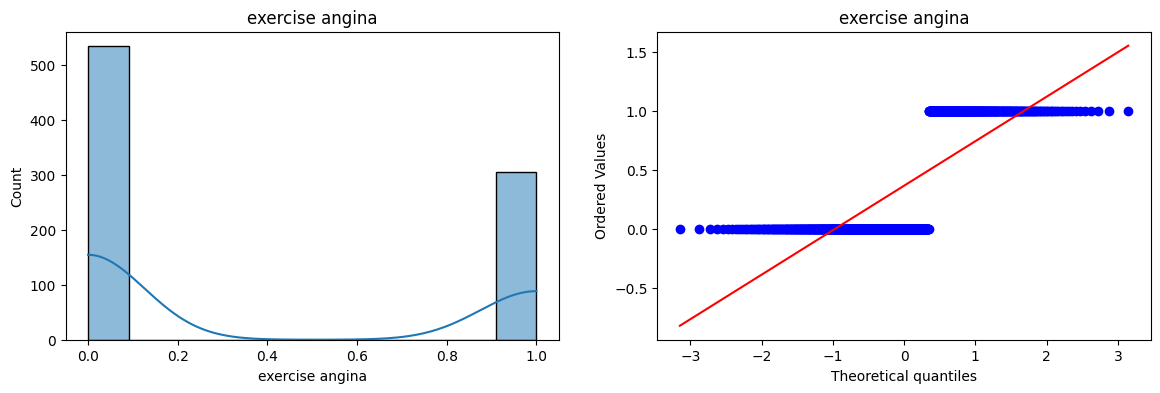

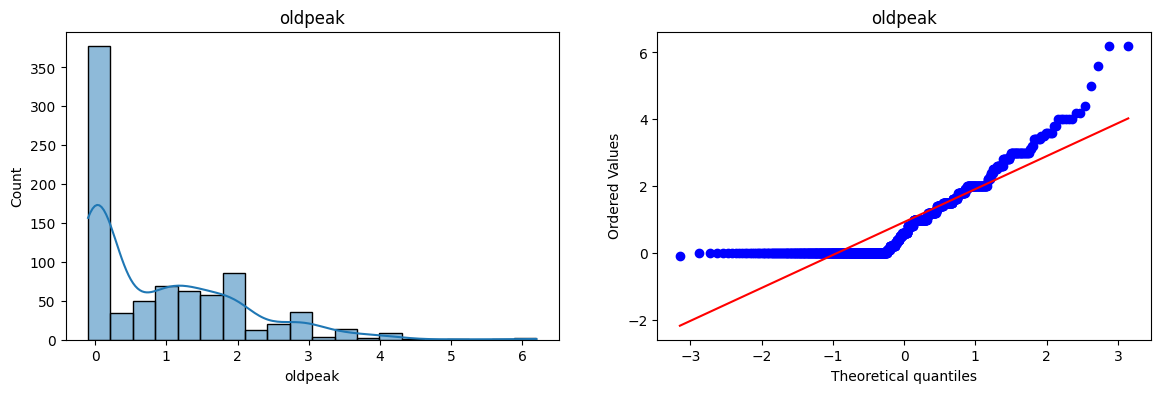

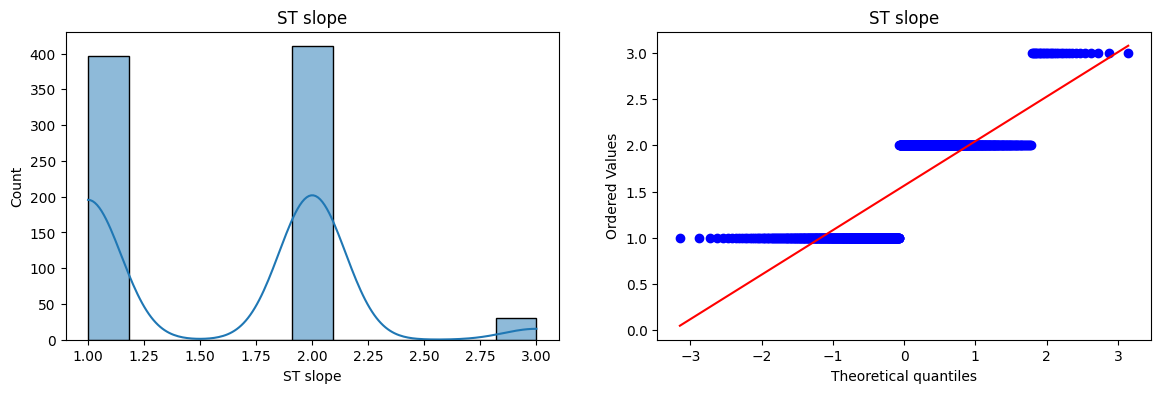

In [19]:
for col in X_train.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde = True)
    plt.title(col)
    
    plt.subplot(122)
    stats.probplot(X_train[col], dist = "norm", plot = plt)
    plt.title(col)
    plt.show()

## Here we see that input features like cholesterol , Age and resting ecg follows Normal Distribution or close to normal distribution. So, here we apply standardization. While, others like 

In [21]:
# --- Step 1: Define the columns for each scaling type ---
standard_cols = ['age', 'max heart rate']
minmax_cols = ['resting bps', 'oldpeak','cholesterol']

# --- Step 2: Create copies of the dataframe ---
df_scaled = df_capped.copy()

# --- Step 3: Apply Standardization ---
standard_scaler = StandardScaler()
df_scaled[standard_cols] = standard_scaler.fit_transform(df_scaled[standard_cols])

# --- Step 4: Apply Min-Max Scaling ---
minmax_scaler = MinMaxScaler()
df_scaled[minmax_cols] = minmax_scaler.fit_transform(df_scaled[minmax_cols])

# --- Step 5: Preview the transformed data ---
print(df_scaled.head())

        age  sex  chest pain type  resting bps  cholesterol  \
0 -1.418599    1                2     0.615385     0.677239   
1 -0.460473    0                3     0.871795     0.270522   
2 -1.737975    1                2     0.487179     0.654851   
3 -0.566932    0                4     0.589744     0.397388   
4  0.071819    1                3     0.743590     0.326493   

   fasting blood sugar  resting ecg  max heart rate  exercise angina  \
0                    0            0        1.191145                0   
1                    0            0        0.535784                0   
2                    0            1       -1.839901                0   
3                    0            0       -1.430300                1   
4                    0            0       -0.856859                0   

    oldpeak  ST slope  target  
0  0.015873       1.0       0  
1  0.174603       2.0       1  
2  0.015873       1.0       0  
3  0.253968       2.0       1  
4  0.015873       1.0       

## Next thing we have to do is feature encoding. 

In [23]:
# --- Step 1: Define your columns ---
onehot_cols = ['chest pain type', 'resting ecg']
ordinal_cols = ['ST slope']

# --- Step 2: Define the encoders ---
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy trap
ordinal_encoder = OrdinalEncoder(categories=[[1, 2, 3]])  # 1 < 2 < 3 (Upsloping < Flat < Downsloping)

# --- Step 3: Combine them using ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', onehot_encoder, onehot_cols),
        ('ordinal', ordinal_encoder, ordinal_cols)
    ],
    remainder='passthrough'  # keep other numeric columns unchanged
)

# --- Step 4: Apply transformation ---
df_encoded = pd.DataFrame(preprocessor.fit_transform(df_scaled), columns=
    list(preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)) +
    ordinal_cols + 
    [col for col in df_scaled.columns if col not in onehot_cols + ordinal_cols]
)
df_encoded

,chest pain type_2,chest pain type_3,chest pain type_4,resting ecg_1,resting ecg_2,ST slope,age,sex,resting bps,cholesterol,fasting blood sugar,max heart rate,exercise angina,oldpeak,target
0,1.0,0.0,0.0,0.0,0.0,0.0,-1.418599,1.0,0.615385,0.677239,0.0,1.191145,0.0,0.015873,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,-0.460473,0.0,0.871795,0.270522,0.0,0.535784,0.0,0.174603,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,-1.737975,1.0,0.487179,0.654851,0.0,-1.839901,0.0,0.015873,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,-0.566932,0.0,0.589744,0.397388,0.0,-1.430300,1.0,0.253968,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.071819,1.0,0.743590,0.326493,0.0,-0.856859,0.0,0.015873,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,0.0,1.0,0.0,0.0,0.0,0.0,1.562237,0.0,0.358974,0.386194,0.0,-1.143579,0.0,0.253968,1.0
1044,0.0,1.0,0.0,1.0,0.0,0.0,-0.992766,0.0,0.205128,0.125000,0.0,1.314025,0.0,0.111111,1.0
1045,0.0,0.0,0.0,1.0,0.0,1.0,-0.141098,1.0,0.461538,0.550373,0.0,0.740584,1.0,0.015873,0.0
1046,0.0,0.0,1.0,0.0,0.0,1.0,0.604111,1.0,0.871795,0.617537,0.0,-0.733979,0.0,0.015873,0.0


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_encoded.drop(columns = ['target']),df_encoded.iloc[:,-1] ,test_size=0.2, random_state=42)

In [175]:


# 8️ Train Logistic Regression.
model1 = LogisticRegression(max_iter=1000, solver='lbfgs')
model1.fit(X_train, y_train)

# 9️ Evaluate.
y_pred = model1.predict(X_test)
print("\n Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Model Performance:
Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.77      0.79       104
         1.0       0.79      0.83      0.81       106

    accuracy                           0.80       210
   macro avg       0.80      0.80      0.80       210
weighted avg       0.80      0.80      0.80       210


Confusion Matrix:
 [[80 24]
 [18 88]]


In [219]:
y_pred = model1.predict(X_test)
y_prob = model1.predict_proba(X_test)[:,1]

In [221]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7857142857142857
Recall: 0.8301886792452831


In [228]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=41
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred1 = rf_model.predict(X_test)

In [230]:
accuracy = accuracy_score(y_test, y_pred1)
precision = precision_score(y_test, y_pred1)
recall = recall_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8
Precision: 0.7758620689655172
Recall: 0.8490566037735849
F1 Score: 0.8108108108108109
